<a href="https://colab.research.google.com/github/JaimRM/QuantitativeFinance/blob/main/backtestedMLstrategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 1. DESCARGA DE DATOS (S&P 500)
print("Descargando datos del S&P 500...")
# Descargamos los últimos 5 años de datos diarios
data = yf.download("^SPX", start="2021-01-01", end="2026-06-01")

# 2. INGENIERÍA DE CARACTERÍSTICAS (Machine Learning Features)
# Limpiamos los nombres de las columnas por si tienen formato MultiIndex
data.columns = [col[0] if isinstance(col, tuple) else col for col in data.columns]

# Feature 1: Retornos de los últimos 2 días
data['Return_2d'] = data['Close'].pct_change(2)
# Feature 2: Retornos de los últimos 5 días (una semana de mercado)
data['Return_5d'] = data['Close'].pct_change(5)
# Feature 3: Volatilidad rodante de 10 días
data['Volatility_10d'] = data['Close'].pct_change().rolling(10).std()
# Feature 4: Relación del precio actual con su Media Móvil de 20 días
data['MA_20'] = data['Close'] / data['Close'].rolling(20).mean()

# 3. DEFINIR LA VARIABLE OBJETIVO (Target)
# Queremos predecir si el precio de MAÑANA subirá (1) o bajará/neutral (0) respecto a HOY
data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)

# Limpiamos los valores NaN generados por las medias móviles y los shifts
data.dropna(inplace=True)

# Seleccionamos las columnas para las X (Features) y la Y (Target)
features = ['Return_2d', 'Return_5d', 'Volatility_10d', 'MA_20']
X = data[features]
y = data['Target']

# 4.DIVISIÓN DE DATOS (Respetando la línea temporal)
split_index = int(len(X) * 0.8)  # 80% entrenamiento, 20% prueba
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 5. ENTRENAMIENTO DEL MODELO
# Usamos Random Forest, que crea múltiples árboles de decisión para evitar el sobreajuste
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
model.fit(X_train, y_train)

# 6. EVALUACIÓN
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n=== RESULTADOS DEL MODELO ===")
print(f"Precisión General (Accuracy): {accuracy:.2%}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Baja/Igual', 'Sube']))

# 7. IMPORTANCIA DE LAS CARACTERÍSTICAS
importances = model.feature_importances_
for name, importance in zip(features, importances):
    print(f"Importancia de {name}: {importance:.2%}")


Descargando datos del S&P 500...


/tmp/ipykernel_20479/1159662642.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^SPX", start="2021-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 completed



=== RESULTADOS DEL MODELO ===
Precisión General (Accuracy): 56.72%

Reporte de Clasificación:
              precision    recall  f1-score   support

  Baja/Igual       0.47      0.24      0.32       113
        Sube       0.59      0.81      0.68       155

    accuracy                           0.57       268
   macro avg       0.53      0.52      0.50       268
weighted avg       0.54      0.57      0.53       268

Importancia de Return_2d: 27.17%
Importancia de Return_5d: 23.60%
Importancia de Volatility_10d: 23.91%
Importancia de MA_20: 25.31%



Iniciando simulación de trading (Backtesting)...

=== RENDIMIENTO DE LA CUENTA SIMULADA ===
Retorno acumulado del Mercado (S&P 500 Buy & Hold): 35.19%
Retorno acumulado de la Estrategia con ML: 25.26%


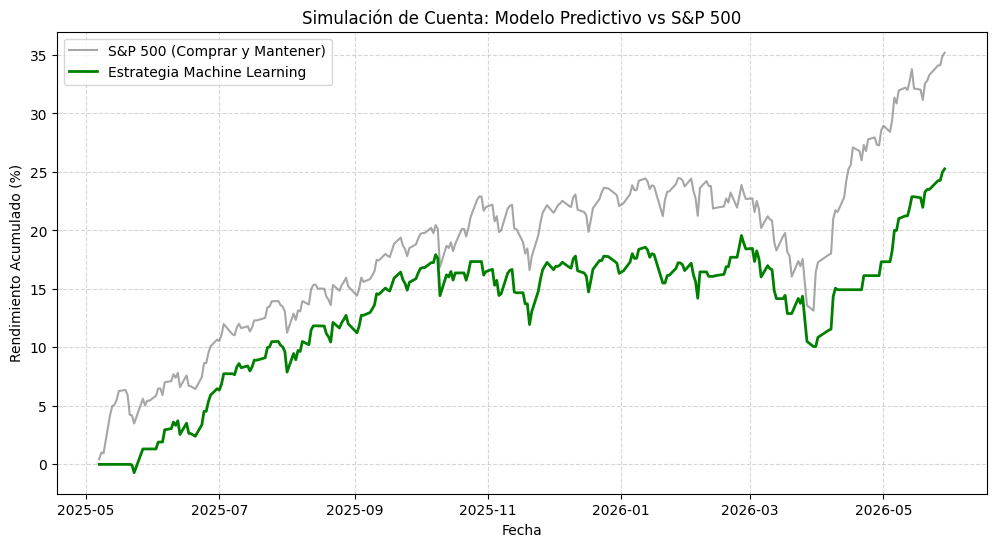

In [2]:
# =====================================================================
# 8. ESTRATEGIA DE BACKTESTING (SIMULACIÓN DE TRADING)
# =====================================================================
print("\nIniciando simulación de trading (Backtesting)...")

# Creamos un DataFrame exclusivo para el análisis del conjunto de prueba (X_test)
backtest_df = pd.DataFrame(index=X_test.index)

# Calculamos los retornos reales diarios del S&P 500 (lo que rinde el mercado por sí solo)
# Usamos el precio de cierre de los datos originales emparejados con el índice de X_test
backtest_df['Market_Daily_Return'] = data.loc[X_test.index, 'Close'].pct_change()

# Guardamos las predicciones de nuestro modelo (0 o 1) en el DataFrame
backtest_df['Model_Signal'] = y_pred

# Estrategia: El retorno de mañana se genera con la señal que el modelo calculó HOY.
# Por lo tanto, desplazamos (shift) la señal 1 día hacia adelante.
backtest_df['Strategy_Daily_Return'] = backtest_df['Market_Daily_Return'] * backtest_df['Model_Signal'].shift(1)

# Limpiamos el primer valor NaN creado por el pct_change() y el shift()
backtest_df.dropna(inplace=True)

# Calculamos los retornos acumulados (Multiplicación compuesta de rendimientos)
backtest_df['Cumulative_Market'] = (1 + backtest_df['Market_Daily_Return']).cumprod() - 1
backtest_df['Cumulative_Strategy'] = (1 + backtest_df['Strategy_Daily_Return']).cumprod() - 1

# 9. IMPRESIÓN DE RENDIMIENTOS FINALES
final_market_return = backtest_df['Cumulative_Market'].iloc[-1]
final_strategy_return = backtest_df['Cumulative_Strategy'].iloc[-1]

print("\n=== RENDIMIENTO DE LA CUENTA SIMULADA ===")
print(f"Retorno acumulado del Mercado (S&P 500 Buy & Hold): {final_market_return:.2%}")
print(f"Retorno acumulado de la Estrategia con ML: {final_strategy_return:.2%}")

# 10. GRÁFICA DE RENDIMIENTO
plt.figure(figsize=(12, 6))
plt.plot(backtest_df['Cumulative_Market'] * 100, label='S&P 500 (Comprar y Mantener)', color='gray', alpha=0.7)
plt.plot(backtest_df['Cumulative_Strategy'] * 100, label='Estrategia Machine Learning', color='green', linewidth=2)
plt.title('Simulación de Cuenta: Modelo Predictivo vs S&P 500')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Acumulado (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
